In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

# Load the CSV files
gist_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/gist_PQ_adc_vs_exact_eval.csv'
deep_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/deep_PQ_adc_vs_exact_eval.csv'

# Load data
df_gist = pd.read_csv(gist_csv)
df_deep = pd.read_csv(deep_csv)

# Add dataset column if not present
df_gist['dataset'] = 'gist'
df_deep['dataset'] = 'deep'

# Filter for train_size == 100000000
df_gist_filtered = df_gist[df_gist['train_size'] == 100000000].copy()
df_deep_filtered = df_deep[df_deep['train_size'] == 100000000].copy()

print(f"Gist dataset (train_size=100M): {len(df_gist_filtered)} rows")
print(f"Deep dataset (train_size=100M): {len(df_deep_filtered)} rows")
print(f"\nGist - n_subquantizers range: {df_gist_filtered['n_subquantizers'].min()} to {df_gist_filtered['n_subquantizers'].max()}")
print(f"Gist - nbits range: {df_gist_filtered['nbits'].min()} to {df_gist_filtered['nbits'].max()}")
print(f"\nDeep - n_subquantizers range: {df_deep_filtered['n_subquantizers'].min()} to {df_deep_filtered['n_subquantizers'].max()}")
print(f"Deep - nbits range: {df_deep_filtered['nbits'].min()} to {df_deep_filtered['nbits'].max()}")


Gist dataset (train_size=100M): 29 rows
Deep dataset (train_size=100M): 31 rows

Gist - n_subquantizers range: 1 to 480
Gist - nbits range: 4 to 16

Deep - n_subquantizers range: 1 to 48
Deep - nbits range: 4 to 16


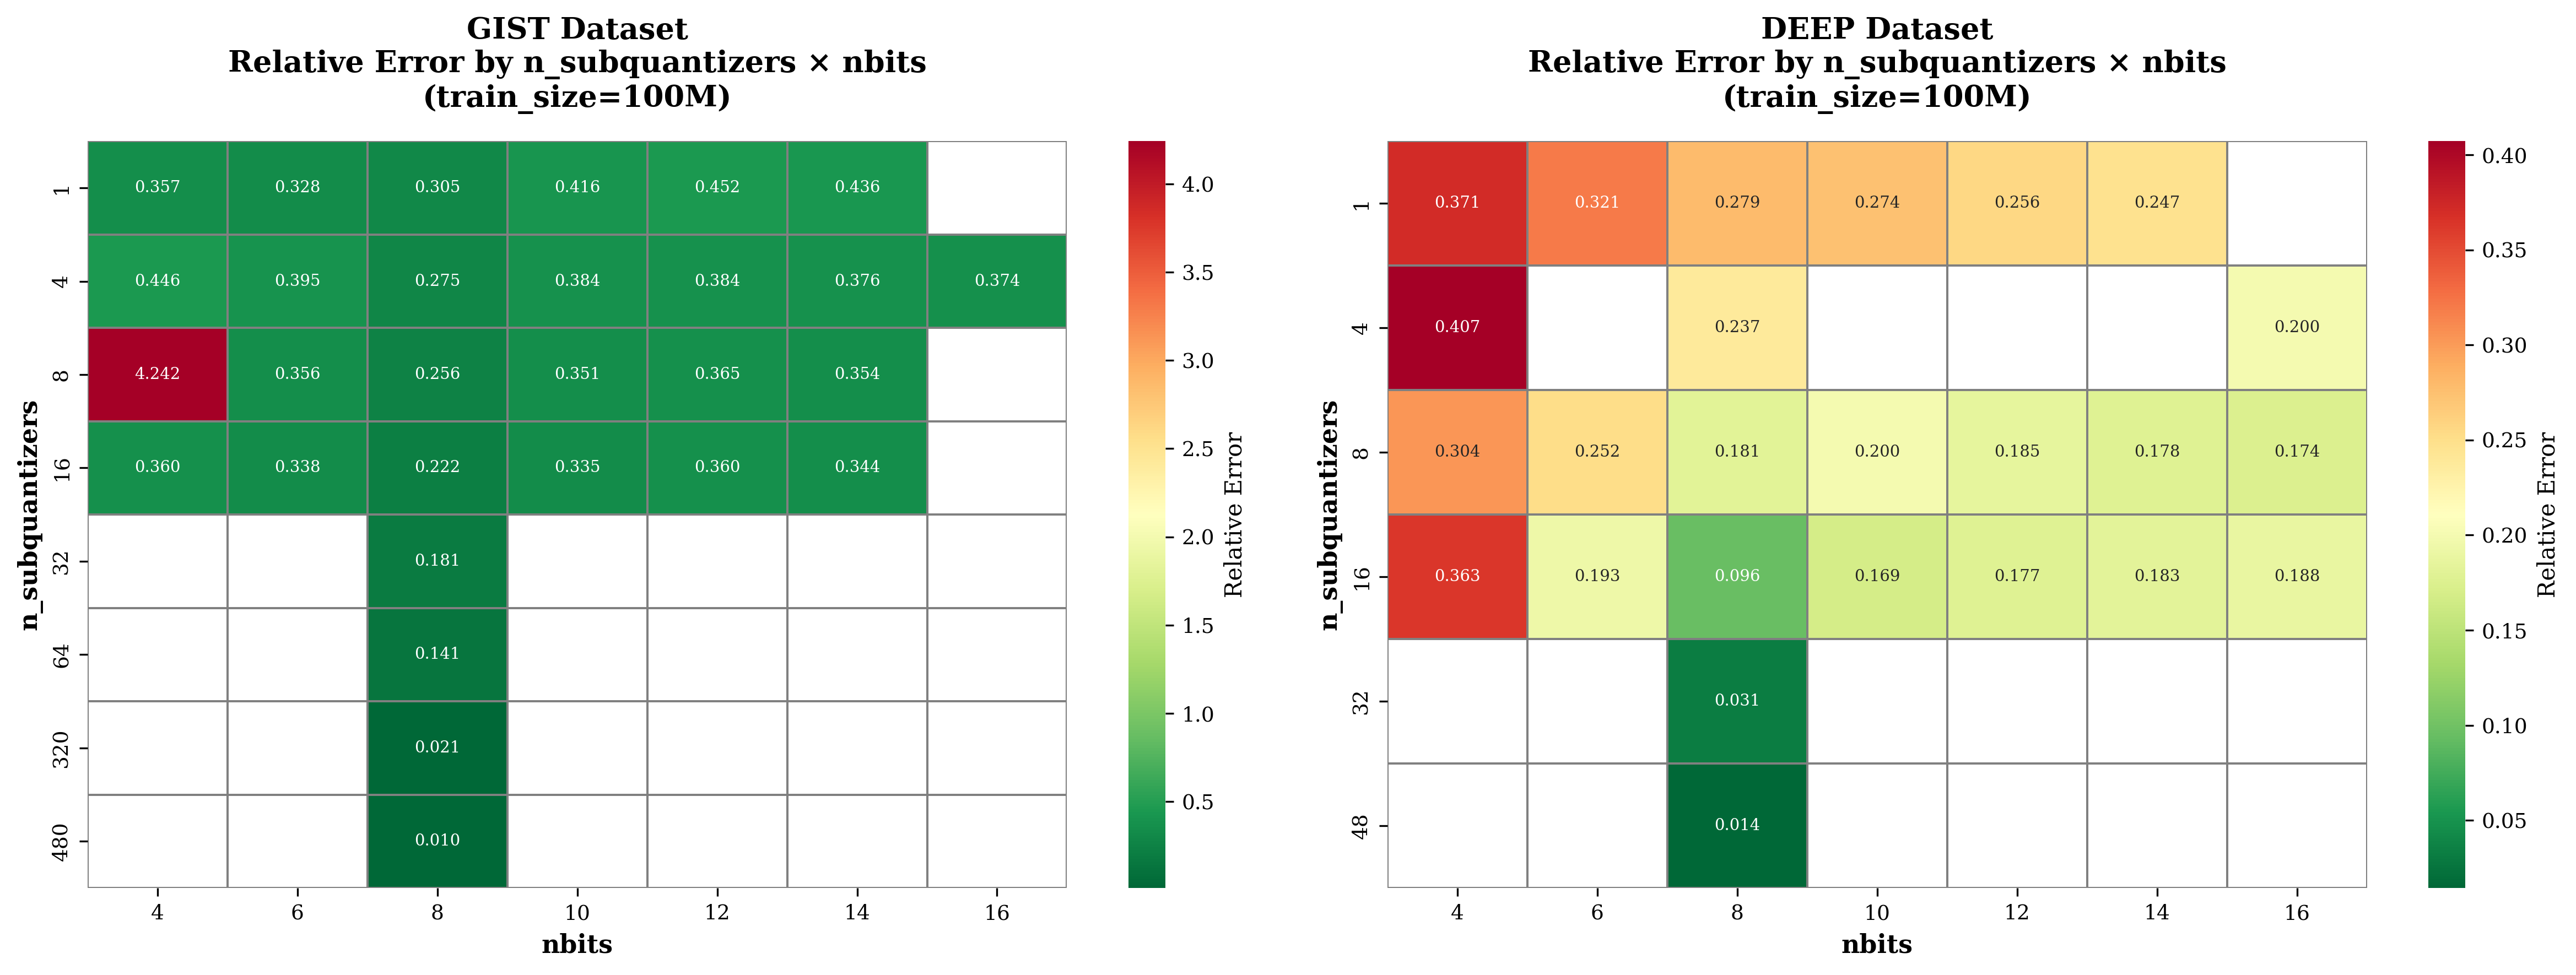

In [11]:
# Set style
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Create heatmaps showing relative error for different combinations of n_subquantizers and nbits
datasets = [
    ('gist', df_gist_filtered),
    ('deep', df_deep_filtered)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[idx]
    
    # Create pivot table for heatmap: n_subquantizers vs nbits
    pivot = df.pivot_table(
        values='rel_error_mean',
        index='n_subquantizers',
        columns='nbits',
        aggfunc='mean'
    )
    
    # Sort index and columns
    pivot = pivot.sort_index()
    pivot = pivot.sort_index(axis=1)
    
    # Create heatmap
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',  # Red-Yellow-Green reversed (lower is better)
        ax=ax,
        cbar_kws={'label': 'Relative Error'},
        linewidths=0.5,
        linecolor='gray',
        annot_kws={'size': 7}
    )
    
    ax.set_title(f'{dataset_name.upper()} Dataset\nRelative Error by n_subquantizers × nbits\n(train_size=100M)', 
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('nbits', fontsize=11, fontweight='bold')
    ax.set_ylabel('n_subquantizers', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


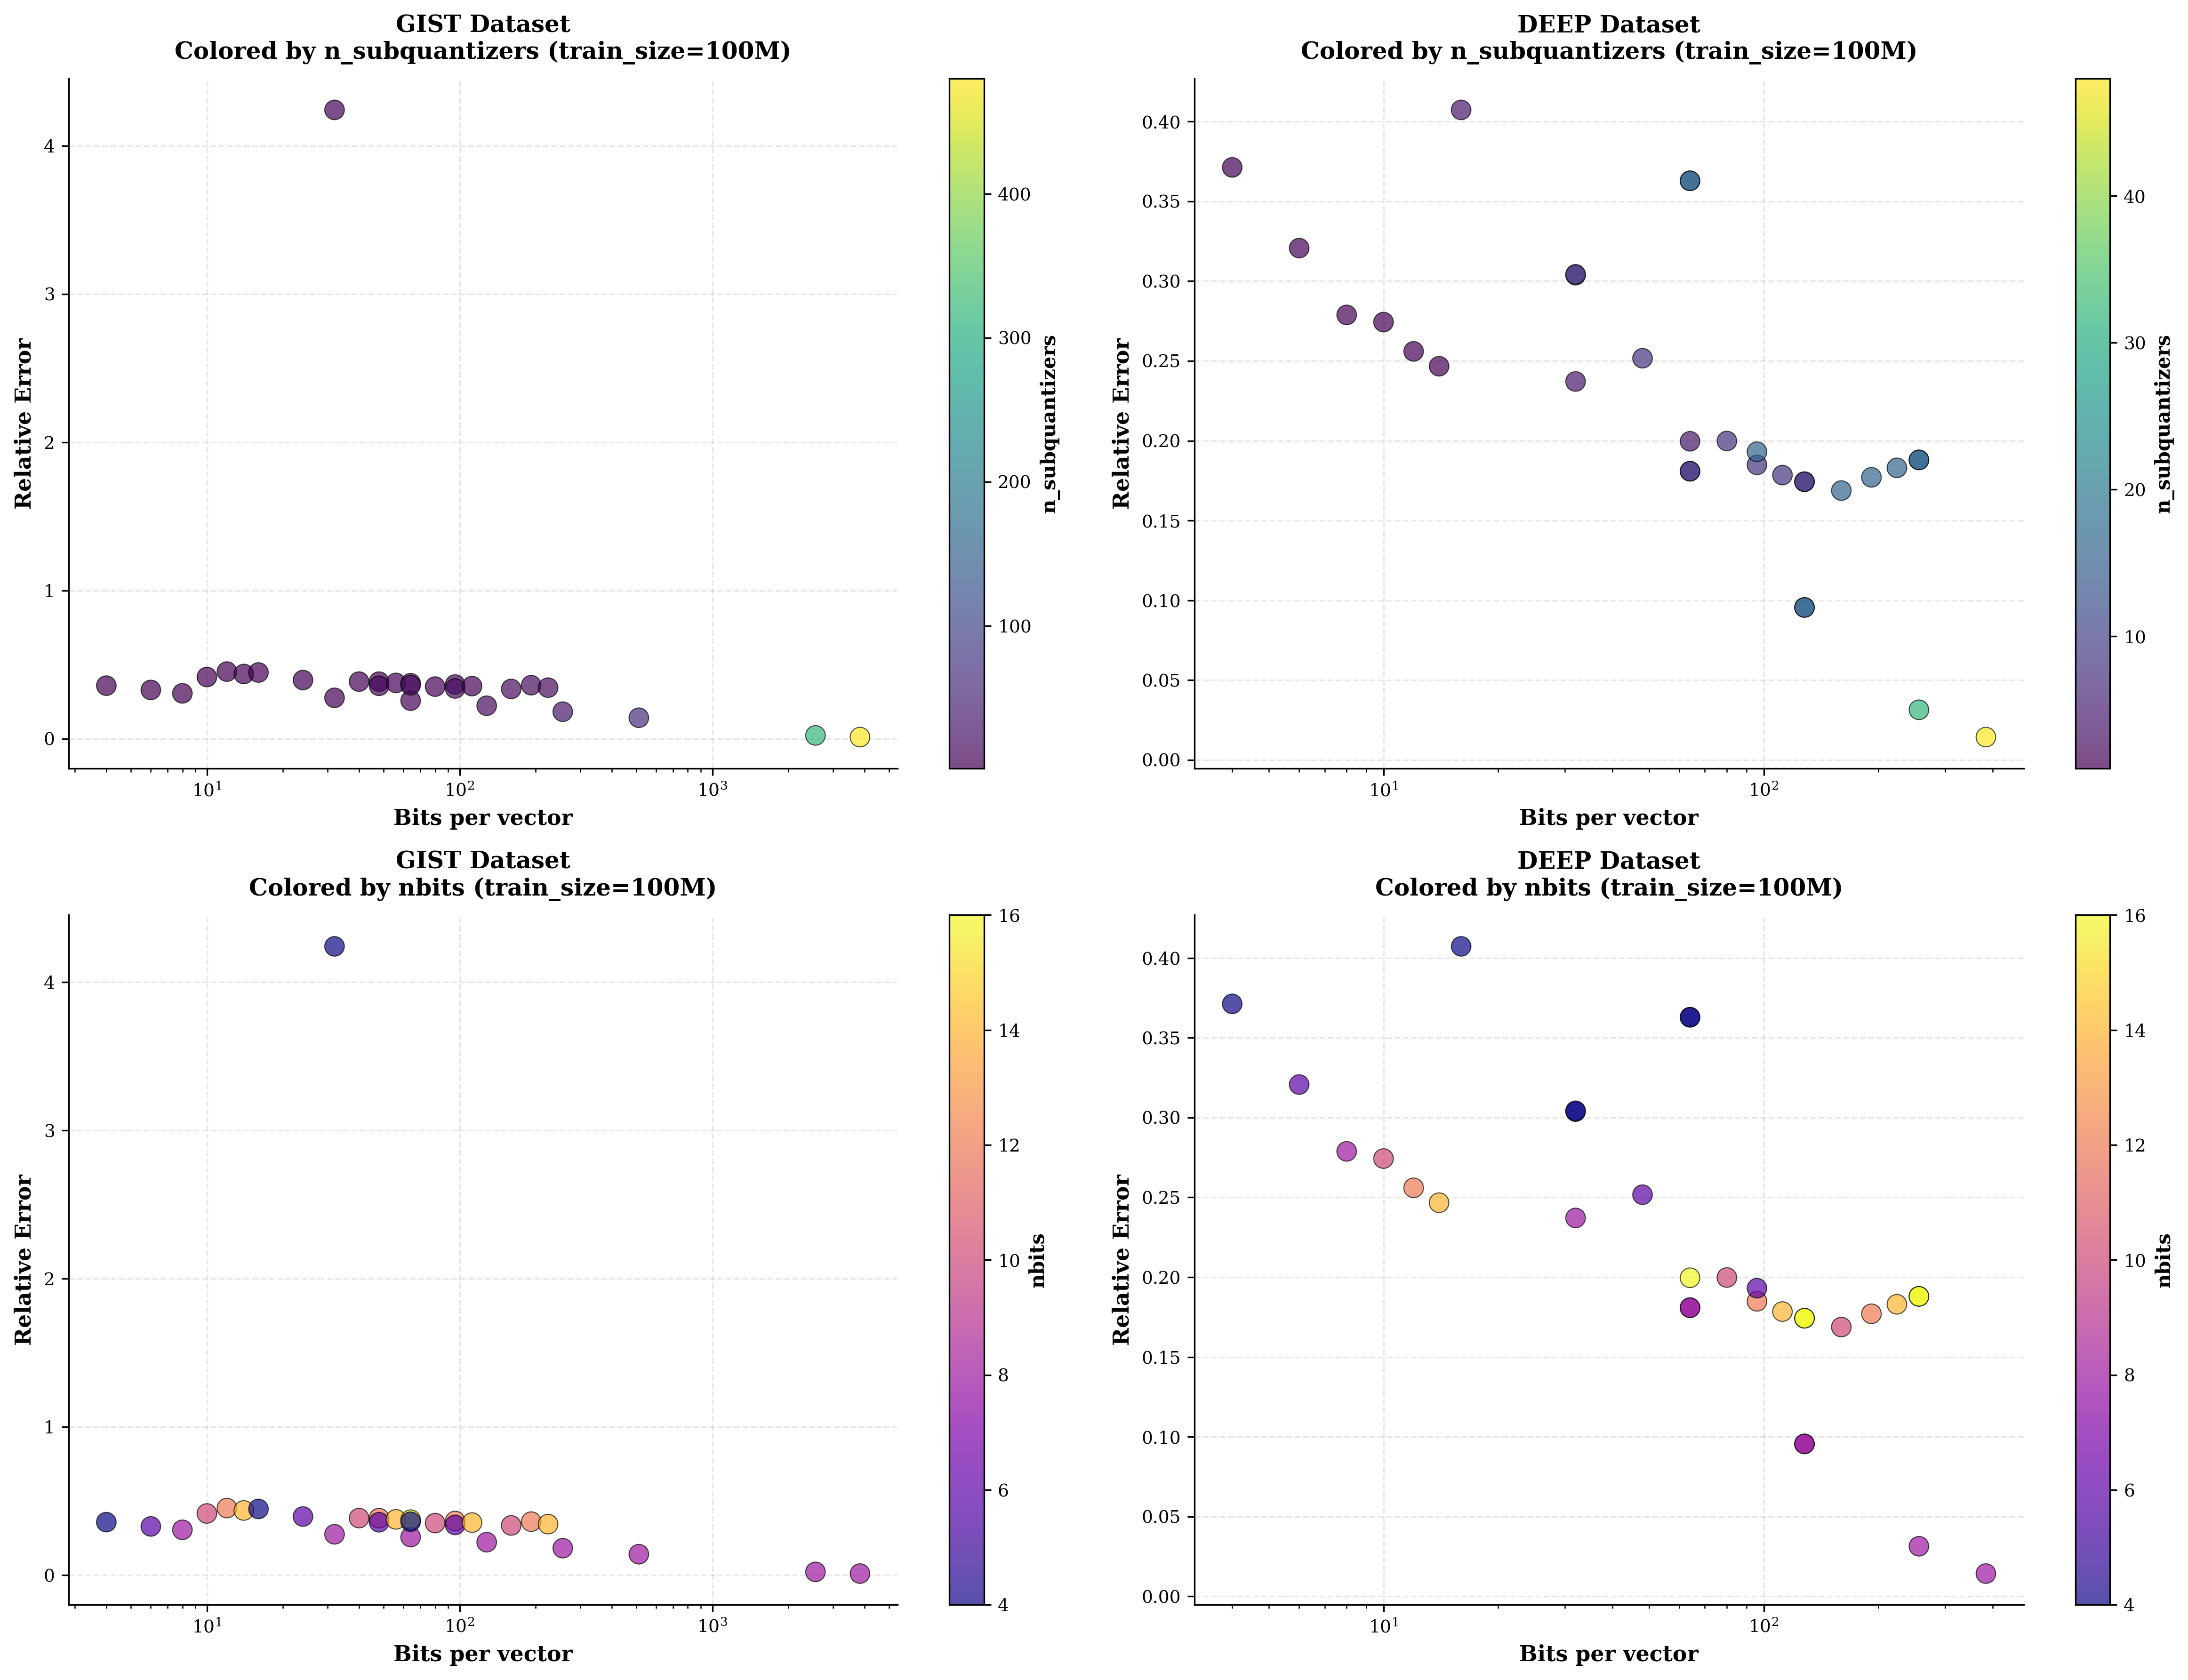

In [12]:
# Visualization 2: Bits per vector vs Relative Error, colored by n_subquantizers and nbits
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top row: Color by n_subquantizers
for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[0, idx]
    
    df_sorted = df.sort_values('bits_per_vector')
    
    # Create scatter plot colored by n_subquantizers
    scatter = ax.scatter(
        df_sorted['bits_per_vector'],
        df_sorted['rel_error_mean'],
        c=df_sorted['n_subquantizers'],
        s=100,
        alpha=0.7,
        cmap='viridis',
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )
    
    ax.set_xscale('log')
    ax.set_xlabel('Bits per vector', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\nColored by n_subquantizers (train_size=100M)', 
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('n_subquantizers', fontsize=10, fontweight='bold')

# Bottom row: Color by nbits
for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[1, idx]
    
    df_sorted = df.sort_values('bits_per_vector')
    
    # Create scatter plot colored by nbits
    scatter = ax.scatter(
        df_sorted['bits_per_vector'],
        df_sorted['rel_error_mean'],
        c=df_sorted['nbits'],
        s=100,
        alpha=0.7,
        cmap='plasma',
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )
    
    ax.set_xscale('log')
    ax.set_xlabel('Bits per vector', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\nColored by nbits (train_size=100M)', 
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('nbits', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


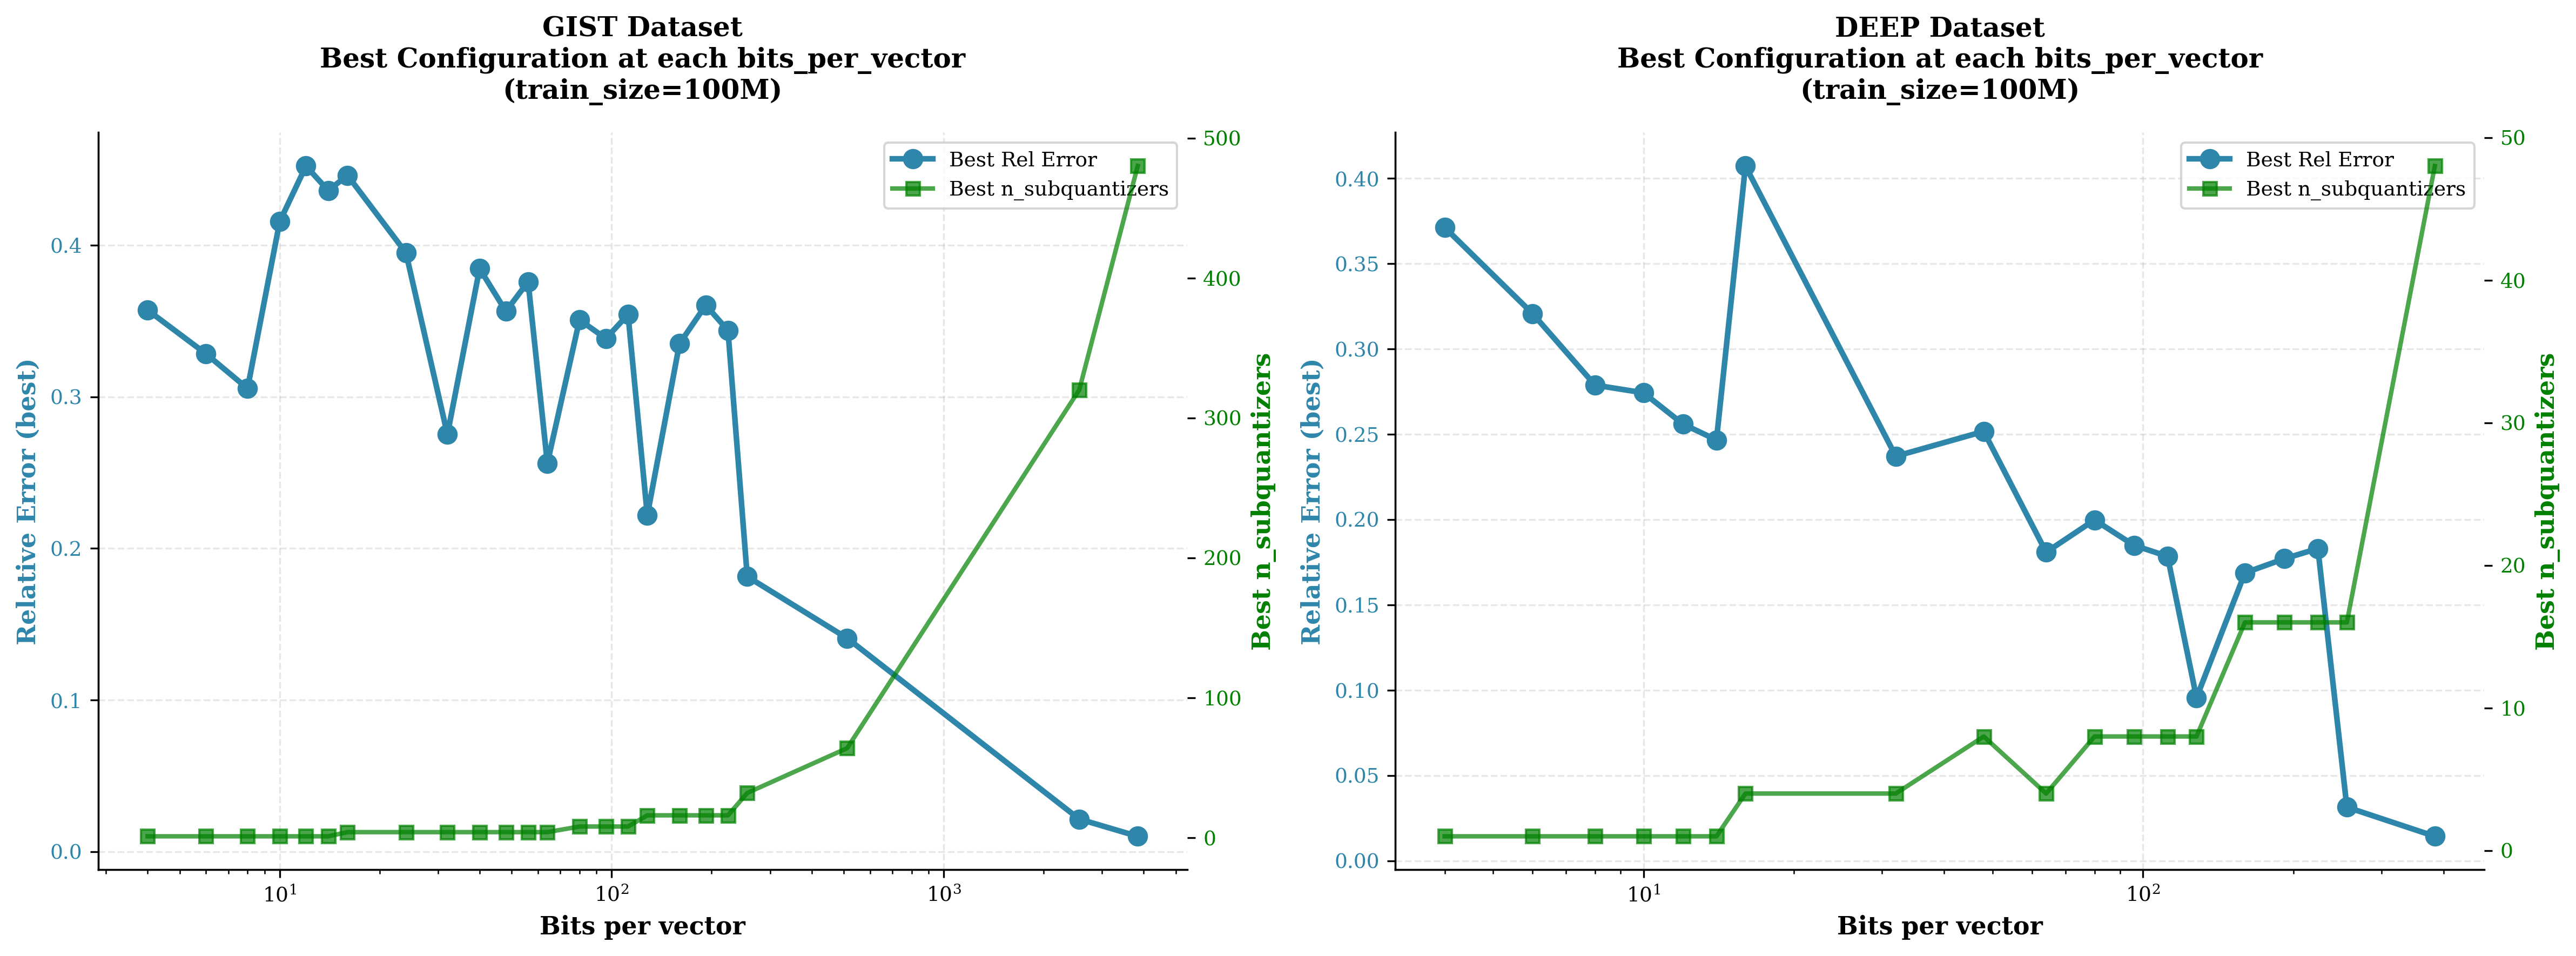


Analysis: Best configurations for each bits_per_vector

GIST Dataset:
Bits/vec     Rel Error    Best n_subq  Best nbits
--------------------------------------------------
4            0.3572       1            4         
6            0.3283       1            6         
8            0.3054       1            8         
10           0.4155       1            10        
12           0.4522       1            12        
14           0.4359       1            14        
16           0.4460       4            4         
24           0.3950       4            6         
32           0.2751       4            4         
40           0.3845       4            10        
48           0.3564       4            6         
56           0.3759       4            14        
64           0.2561       4            4         
80           0.3507       8            10        
96           0.3384       8            6         
112          0.3542       8            14        
128          0.2218       16

In [13]:
# Visualization 3: Grouped by bits_per_vector, show contribution of n_subquantizers vs nbits
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[idx]
    
    # Group by bits_per_vector and find best configurations
    grouped = df.groupby('bits_per_vector').agg({
        'rel_error_mean': ['min', 'mean', 'std'],
        'n_subquantizers': lambda x: df.loc[x.idxmin(), 'n_subquantizers'] if len(x) > 0 else np.nan,
        'nbits': lambda x: df.loc[x.idxmin(), 'nbits'] if len(x) > 0 else np.nan
    }).reset_index()
    
    grouped.columns = ['bits_per_vector', 'rel_error_min', 'rel_error_mean', 'rel_error_std', 
                       'best_n_subquantizers', 'best_nbits']
    grouped = grouped.sort_values('bits_per_vector')
    
    # Plot lines for best n_subquantizers and best nbits for each bits_per_vector
    ax2 = ax.twinx()
    
    # Left y-axis: relative error
    line1 = ax.plot(grouped['bits_per_vector'], grouped['rel_error_min'], 
                    marker='o', markersize=8, linewidth=2.5, color='#2E86AB', 
                    label='Best Rel Error', zorder=3)
    
    # Right y-axis: best n_subquantizers
    line2 = ax2.plot(grouped['bits_per_vector'], grouped['best_n_subquantizers'], 
                     marker='s', markersize=6, linewidth=2, color='green', 
                     alpha=0.7, label='Best n_subquantizers', zorder=2)
    
    ax.set_xscale('log')
    ax.set_xlabel('Bits per vector', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Error (best)', fontsize=11, fontweight='bold', color='#2E86AB')
    ax2.set_ylabel('Best n_subquantizers', fontsize=11, fontweight='bold', color='green')
    ax.set_title(f'{dataset_name.upper()} Dataset\nBest Configuration at each bits_per_vector\n(train_size=100M)', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.tick_params(axis='y', labelcolor='#2E86AB')
    ax2.tick_params(axis='y', labelcolor='green')
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("Analysis: Best configurations for each bits_per_vector")
print("="*80)
for dataset_name, df in datasets:
    grouped = df.groupby('bits_per_vector').agg({
        'rel_error_mean': 'min',
        'n_subquantizers': lambda x: df.loc[x.idxmin(), 'n_subquantizers'],
        'nbits': lambda x: df.loc[x.idxmin(), 'nbits']
    }).reset_index()
    grouped.columns = ['bits_per_vector', 'rel_error_min', 'best_n_subquantizers', 'best_nbits']
    grouped = grouped.sort_values('bits_per_vector')
    
    print(f"\n{dataset_name.upper()} Dataset:")
    print(f"{'Bits/vec':<12} {'Rel Error':<12} {'Best n_subq':<12} {'Best nbits':<10}")
    print("-" * 50)
    for _, row in grouped.iterrows():
        print(f"{int(row['bits_per_vector']):<12} {row['rel_error_min']:<12.4f} {int(row['best_n_subquantizers']):<12} {int(row['best_nbits']):<10}")


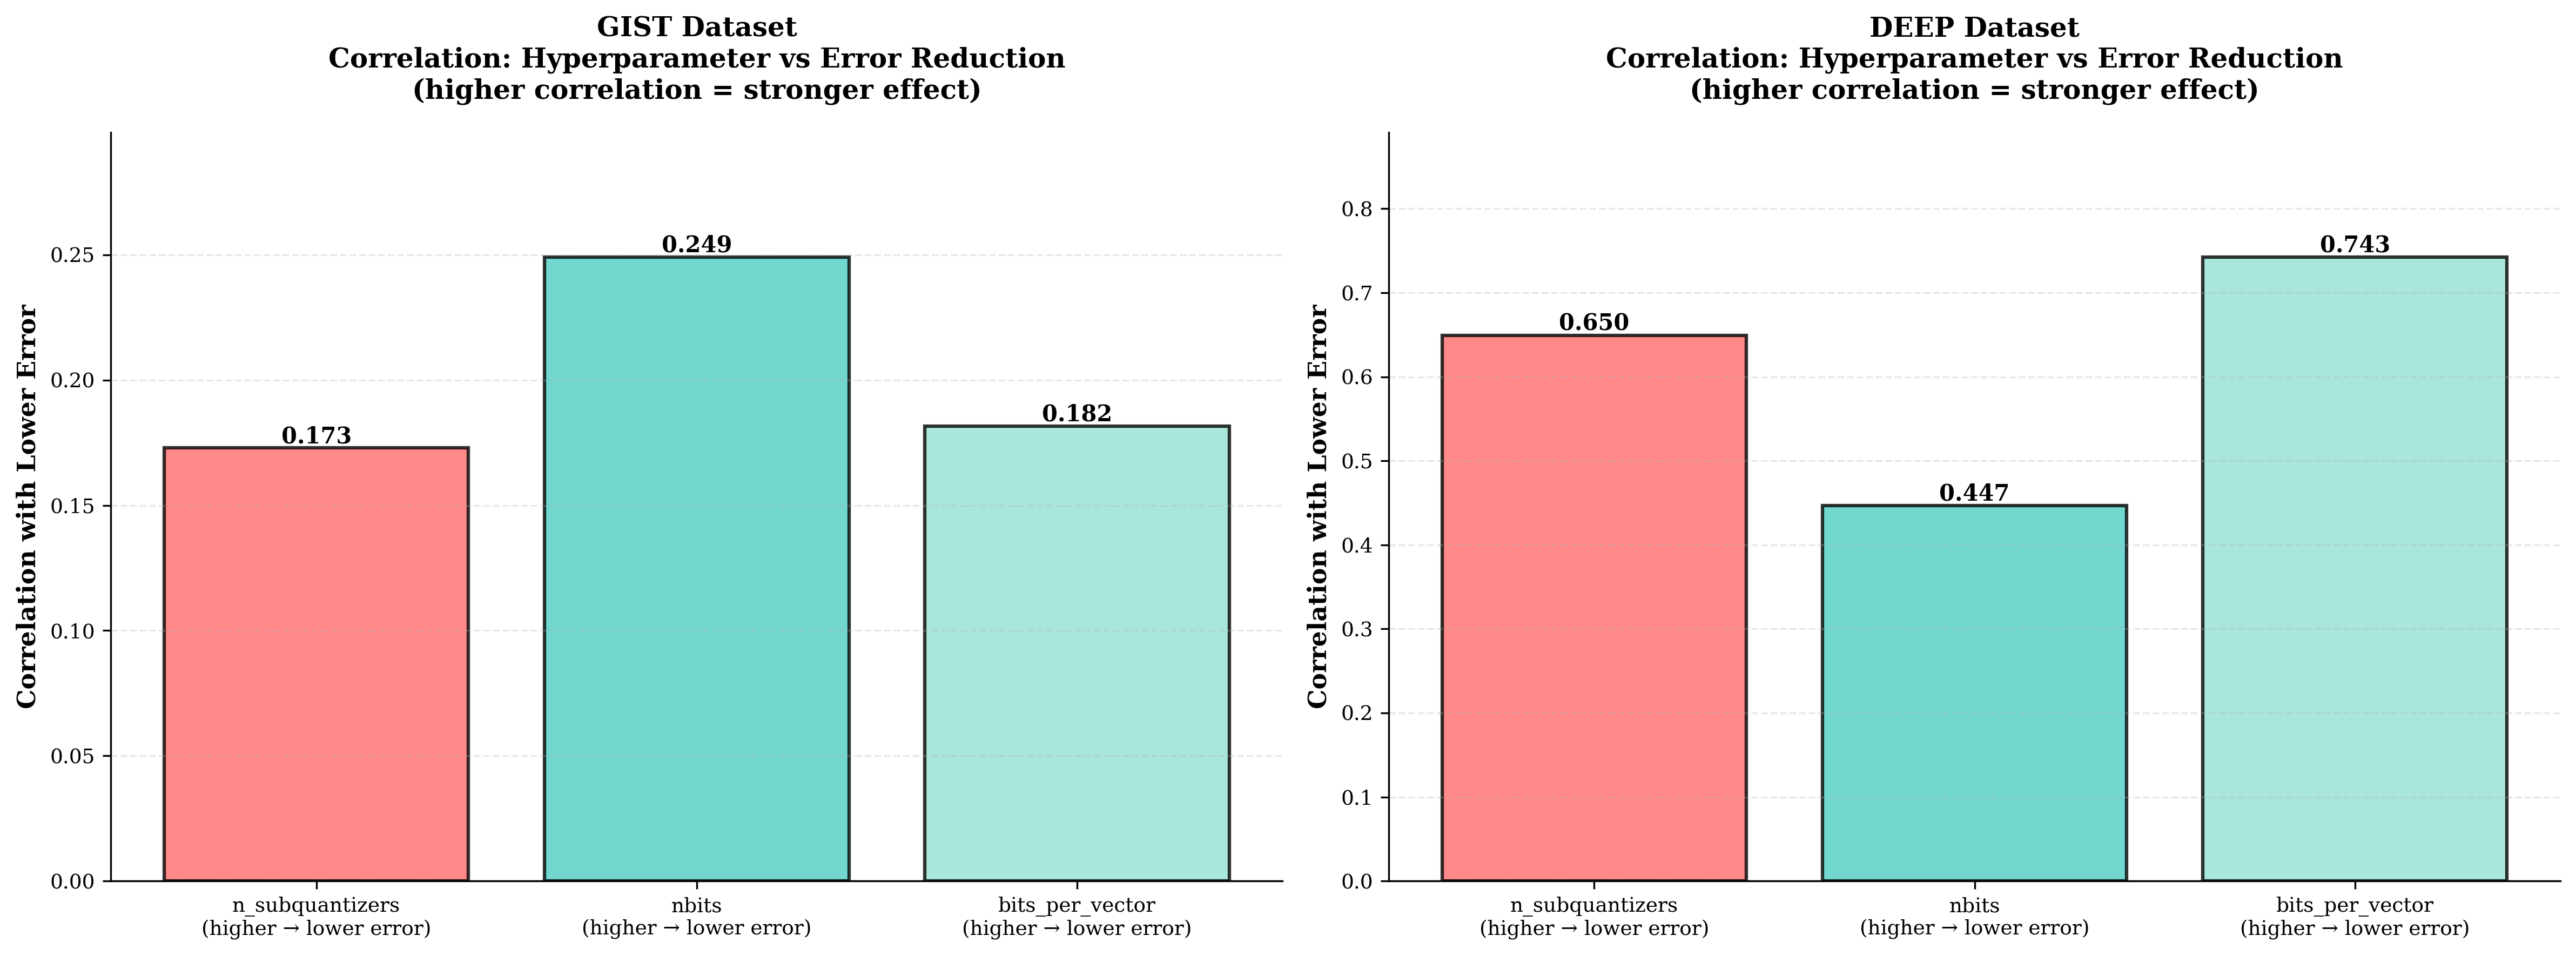


Correlation Analysis: Which hyperparameter contributes most to lower error?
(Negative correlation with error = positive correlation with lower error)
Higher absolute correlation = stronger effect

GIST Dataset:
  n_subquantizers: 0.1730
  nbits: 0.2492
  bits_per_vector: 0.1817
  → nbits has stronger effect

DEEP Dataset:
  n_subquantizers: 0.6495
  nbits: 0.4471
  bits_per_vector: 0.7426
  → n_subquantizers has stronger effect



In [14]:
# Visualization 4: Correlation analysis - which contributes more to low error?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[idx]
    
    # Calculate correlations
    corr_nsub = df['n_subquantizers'].corr(-df['rel_error_mean'])  # Negative because more subquantizers = lower error
    corr_nbits = df['nbits'].corr(-df['rel_error_mean'])
    corr_bpv = df['bits_per_vector'].corr(-df['rel_error_mean'])
    
    # Create bar plot comparing correlations
    categories = ['n_subquantizers\n(higher → lower error)', 
                  'nbits\n(higher → lower error)', 
                  'bits_per_vector\n(higher → lower error)']
    correlations = [corr_nsub, corr_nbits, corr_bpv]
    colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
    
    bars = ax.bar(categories, correlations, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, corr in zip(bars, correlations):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{corr:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Correlation with Lower Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\nCorrelation: Hyperparameter vs Error Reduction\n(higher correlation = stronger effect)', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(correlations) * 1.2)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, axis='y')
    ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print correlation summary
print("\n" + "="*80)
print("Correlation Analysis: Which hyperparameter contributes most to lower error?")
print("="*80)
print("(Negative correlation with error = positive correlation with lower error)")
print("Higher absolute correlation = stronger effect\n")
for dataset_name, df in datasets:
    corr_nsub = df['n_subquantizers'].corr(-df['rel_error_mean'])
    corr_nbits = df['nbits'].corr(-df['rel_error_mean'])
    corr_bpv = df['bits_per_vector'].corr(-df['rel_error_mean'])
    
    print(f"{dataset_name.upper()} Dataset:")
    print(f"  n_subquantizers: {corr_nsub:.4f}")
    print(f"  nbits: {corr_nbits:.4f}")
    print(f"  bits_per_vector: {corr_bpv:.4f}")
    print(f"  → {'n_subquantizers' if abs(corr_nsub) > abs(corr_nbits) else 'nbits'} has stronger effect")
    print()


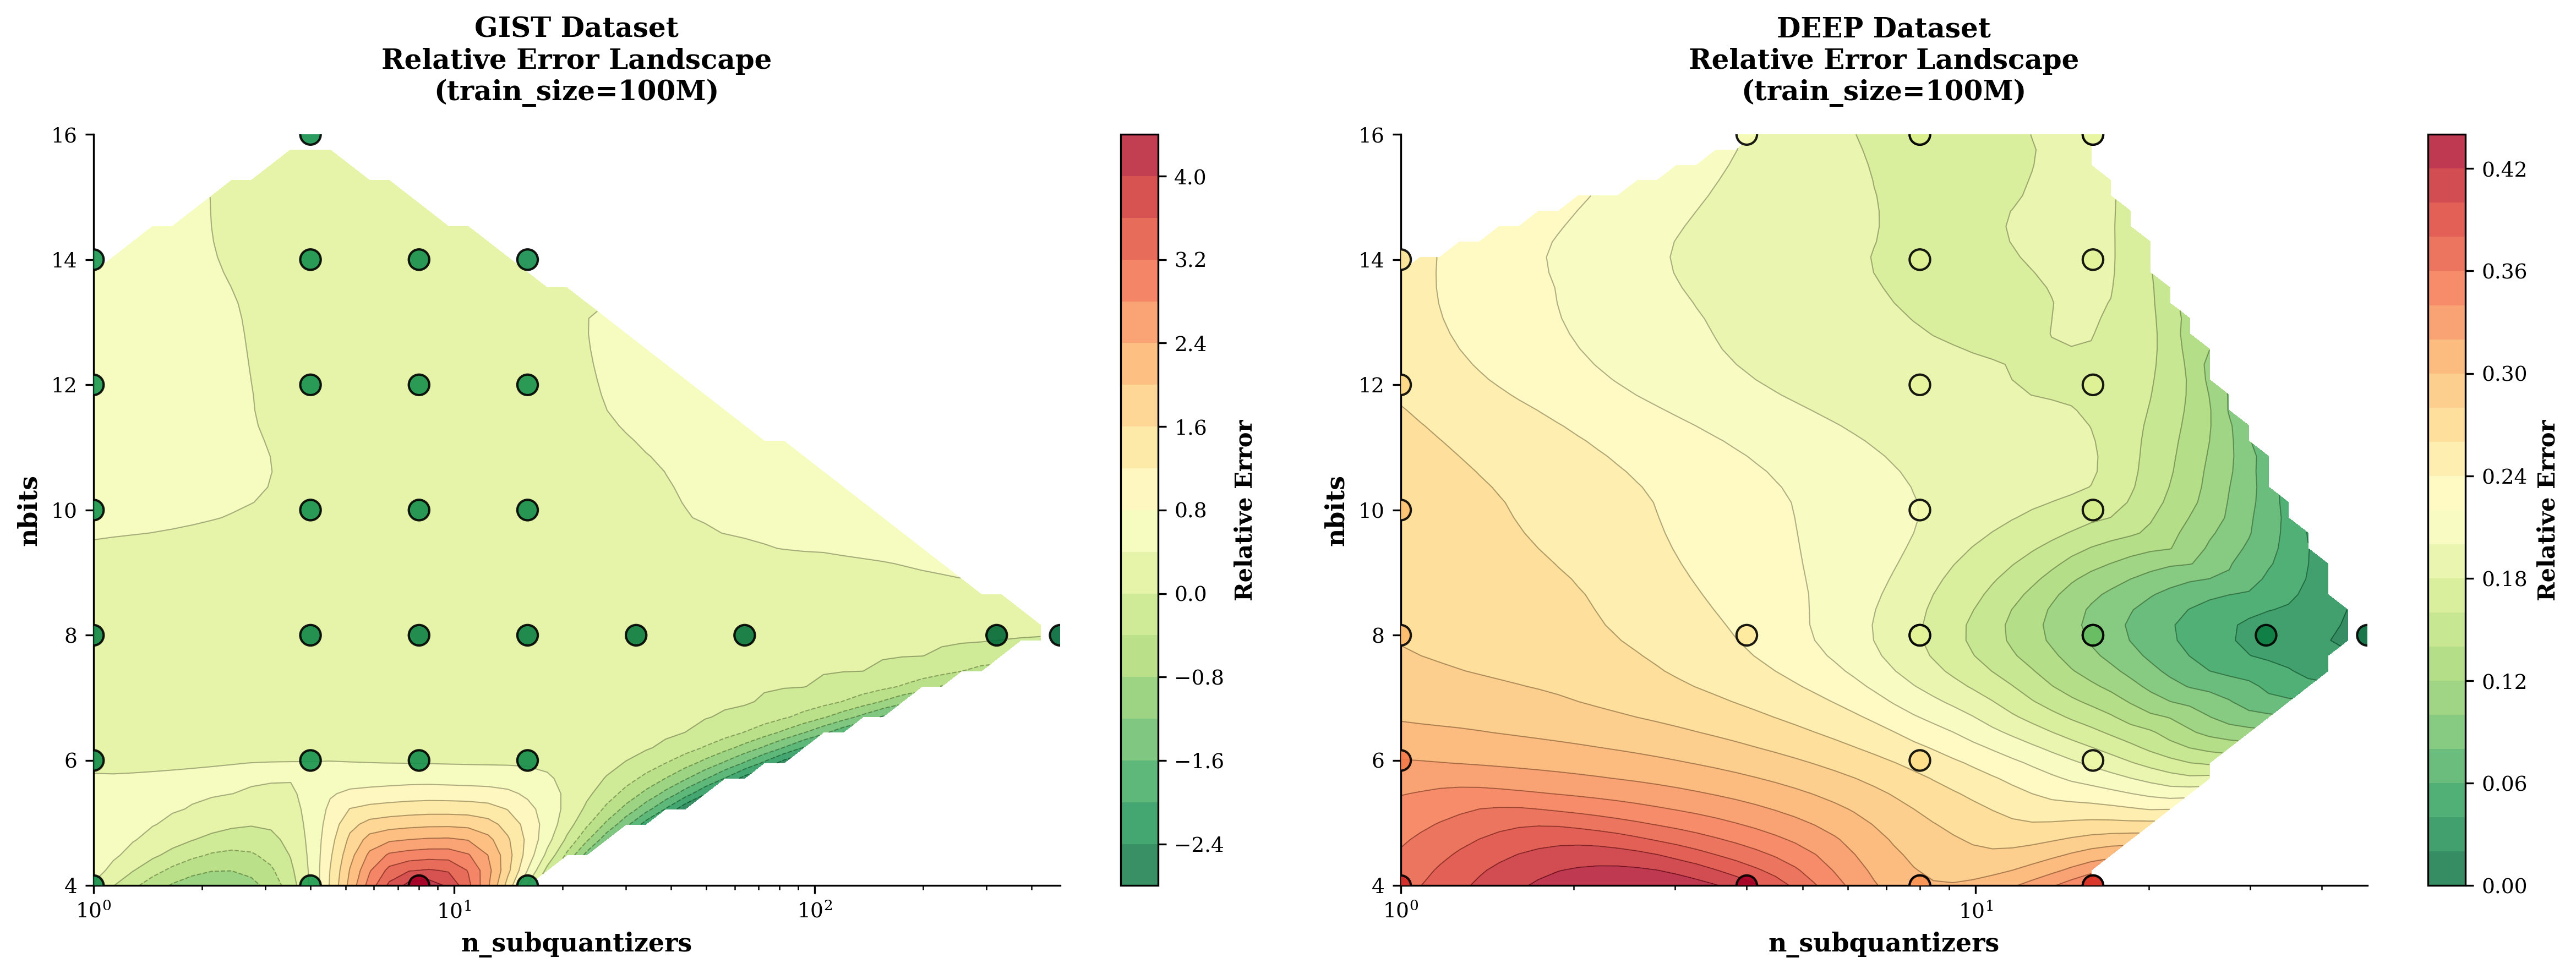

In [15]:
# Visualization 5: Contour plots showing relative error landscape
from scipy.interpolate import griddata

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[idx]
    
    # Create grid for interpolation
    nsub_min, nsub_max = df['n_subquantizers'].min(), df['n_subquantizers'].max()
    nbits_min, nbits_max = df['nbits'].min(), df['nbits'].max()
    
    # Use log scale for n_subquantizers due to wide range
    nsub_log_min, nsub_log_max = np.log10(nsub_min), np.log10(nsub_max)
    nbits_min, nbits_max = int(nbits_min), int(nbits_max)
    
    # Create grid
    nsub_grid_log = np.linspace(nsub_log_min, nsub_log_max, 50)
    nbits_grid = np.linspace(nbits_min, nbits_max, 50)
    NSUB_LOG, NBITS = np.meshgrid(nsub_grid_log, nbits_grid)
    NSUB = 10 ** NSUB_LOG
    
    # Interpolate relative error
    points = np.column_stack([np.log10(df['n_subquantizers']), df['nbits']])
    values = df['rel_error_mean'].values
    
    rel_error_grid = griddata(points, values, (NSUB_LOG, NBITS), method='cubic', fill_value=np.nan)
    
    # Create contour plot
    contour = ax.contourf(NSUB, NBITS, rel_error_grid, levels=20, cmap='RdYlGn_r', alpha=0.8)
    ax.contour(NSUB, NBITS, rel_error_grid, levels=20, colors='black', alpha=0.3, linewidths=0.5)
    
    # Overlay actual data points
    scatter = ax.scatter(df['n_subquantizers'], df['nbits'], 
                        c=df['rel_error_mean'], s=80, 
                        cmap='RdYlGn_r', edgecolors='black', 
                        linewidths=1, zorder=5, alpha=0.9)
    
    ax.set_xscale('log')
    ax.set_xlabel('n_subquantizers', fontsize=11, fontweight='bold')
    ax.set_ylabel('nbits', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\nRelative Error Landscape\n(train_size=100M)', 
                 fontsize=12, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Relative Error', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


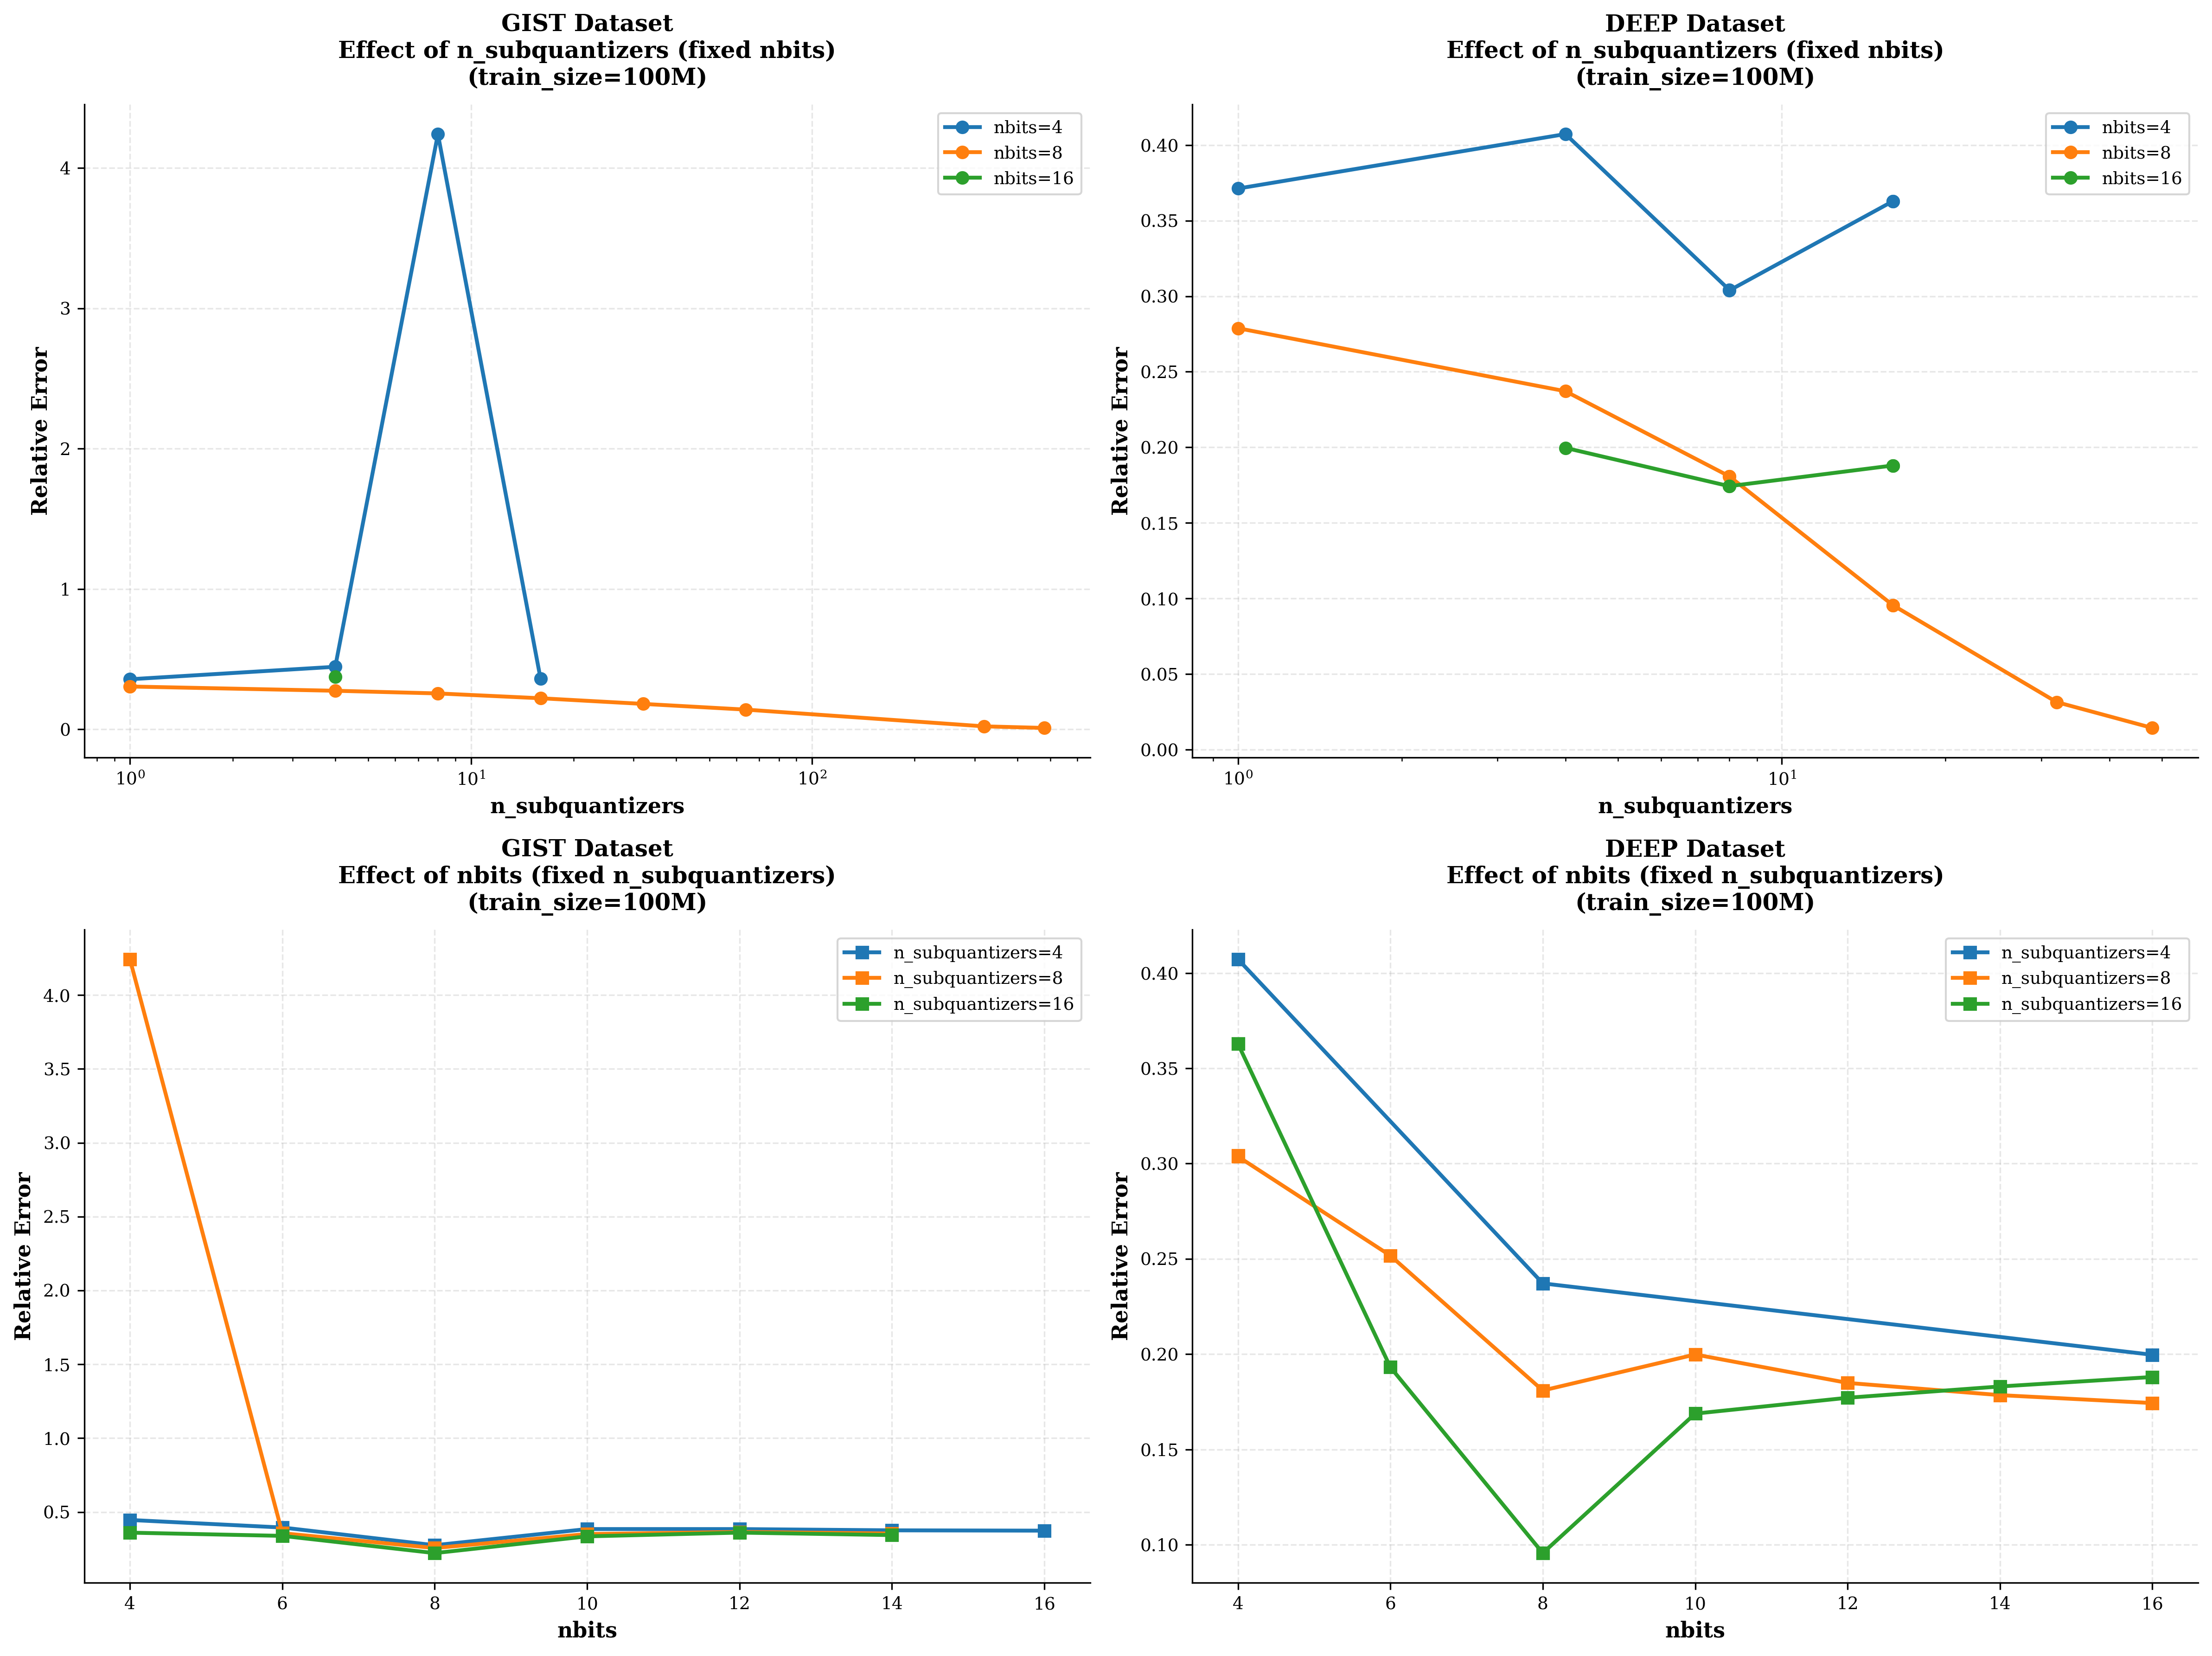

In [16]:
# Visualization 6: Marginal effects - keeping one parameter fixed, vary the other
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top row: Vary n_subquantizers while keeping nbits constant
common_nbits = [4, 8, 16]  # Common nbits values

for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[0, idx]
    
    for nbits_val in common_nbits:
        df_nbits = df[df['nbits'] == nbits_val]
        if len(df_nbits) > 0:
            df_sorted = df_nbits.sort_values('n_subquantizers')
            ax.plot(df_sorted['n_subquantizers'], df_sorted['rel_error_mean'],
                   marker='o', markersize=6, linewidth=2, label=f'nbits={nbits_val}')
    
    ax.set_xscale('log')
    ax.set_xlabel('n_subquantizers', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\nEffect of n_subquantizers (fixed nbits)\n(train_size=100M)', 
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.legend(fontsize=9)

# Bottom row: Vary nbits while keeping n_subquantizers constant
common_nsub = [4, 8, 16]  # Common n_subquantizers values

for idx, (dataset_name, df) in enumerate(datasets):
    ax = axes[1, idx]
    
    for nsub_val in common_nsub:
        df_nsub = df[df['n_subquantizers'] == nsub_val]
        if len(df_nsub) > 0:
            df_sorted = df_nsub.sort_values('nbits')
            ax.plot(df_sorted['nbits'], df_sorted['rel_error_mean'],
                   marker='s', markersize=6, linewidth=2, label=f'n_subquantizers={nsub_val}')
    
    ax.set_xlabel('nbits', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\nEffect of nbits (fixed n_subquantizers)\n(train_size=100M)', 
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.legend(fontsize=9)
    ax.set_xticks(sorted(df['nbits'].unique()))

plt.tight_layout()
plt.show()
